## **_Sample Modeling V4.3_** (for Reinforcement Learning)

* 이 페이지는 "Drying Oven"의 가상 센서 데이터를 이용하여 PPO 모델을 교육하고 예측하는 예제를 구현합니다.
* PPO는 기본적으로 Linear 모델을 지원합니다.
* pip install numpy pandas tensor ipykernel torch scikit-learn gymnasium stable_baselines3

In [26]:
# ----------------------------------------------------
# Global 변수 선언
# ----------------------------------------------------
import os
import sys
from pathlib import Path
from datetime import datetime

csv_file_pathname = lambda: f".{os.sep}data{os.sep}ppolstm_dryer_sensor_v4.3_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
model_path_name = lambda: f".{os.sep}model{os.sep}ppolstm_dryer_v4.3_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pth"
global_num_samples = 51200
parent_dir = os.path.dirname(os.getcwd())
project_home_dir = str(Path.cwd().parent.parent)
venv_name = "samplemodelingv4_3"
const_heater_input = 14.5

reward_gen_fn="lib/reward/dryer_oven/gen_reward_v1.py"
reward_gen_fn = reward_gen_fn.replace("/", os.sep)
reward_gen_fn_pythonfile = project_home_dir + os.sep + reward_gen_fn
simulation_cls_pathname = "lib/simulate/dryer_oven_simulation.py"
simulation_cls_pathname = simulation_cls_pathname.replace("/", os.sep)
simulation_cls_pathname = project_home_dir + os.sep + simulation_cls_pathname


In [27]:
# ----------------------------------------------------
# 개발 환경 초기화
# 한 번만 호출하여 주십시요.


# 1.1 set pythonpath to import from parent directory
def _init_environ():
    python_path = os.environ.get("PYTHONPATH")
    if python_path is None:
        python_path = ""
    sys.path.append(parent_dir)
    sys.path.append(project_home_dir)
    python_lib_path = [
        f'{project_home_dir}{os.sep}{venv_name}{os.sep}{"Lib" if sys.platform == "win32" else "lib"}{os.sep}site-packages',
        project_home_dir,
        python_path
    ]
    os.environ["PYTHONPATH"] = ";".join(python_lib_path)

    os.environ["CLEARML_WEB_HOST"] = "http://172.16.8.168:8080/"
    os.environ["CLEARML_API_HOST"] = "http://172.16.8.168:8008/"
    os.environ["CLEARML_FILES_HOST"] = "http://172.16.8.168:8081"
    os.environ["CLEARML_API_ACCESS_KEY"] = "SIJ8V8YP9PL25YEAVAWGP9NV11TMOQ"
    os.environ["CLEARML_API_SECRET_KEY"] = "6x_MEHvgrUv9-TFFDrE9BE7vb3JYOXDWq4kQtqbd58nQ5pqHEGMt6qQXxF7_HCyzq7E"

_init_environ()


**_1. 한 번의 업데이트에 사용되는 로우 수_**

RecurrentPPO는 설정된 환경(envs)들이 동시에 데이터를 수집합니다.
- 공식: n_steps × n_envs = 512 로우
- 즉, 모델은 512개의 데이터가 모일 때마다 가중치를 업데이트합니다.

**_2. 학습에 적당한 전체 데이터 로우 수_**
건조기 제어와 같은 시뮬레이션 환경이라면, 단순히 로우 수보다 '에피소드(공정 완료)를 얼마나 반복했는가'가 중요합니다.

- 최소 권장: 업데이트 횟수가 최소 100회 이상은 되어야 학습이 일어납니다.
  - 512 * 100 로우 이상
- 안정적 학습: 보통 건조기 물리 엔진을 충분히 이해하려면 20만 ~ 50만 로우 정도의 경험이 필요합니다.
  - 약 200,000 ~ 500,000 로우

In [28]:
!echo $PYTHONPATH
from lib.simulate.dryer_oven_data_genetate import generate_data_v1
from lib.simulate.dryer_oven_data_genetate_v2 import generate_data_v2

# 1. 설정값 초기화
num_samples = global_num_samples
target_temp = 80
initial_temp = 25
drop_envs = [(0.4, 100, 30), (0.5, 200, 40)]
spike_envs = [(0.6, 300, 50), (0.7, 200, 40), (0.8, 200, 70)]
# drop_envs = []
# spike_envs = []

verbose = 0


gen_functions = {"v1": generate_data_v1, "v2": generate_data_v2}
cur_version = "v2"

stored_data_file_pathname = gen_functions[cur_version](drop_envs=drop_envs,
                                                       spike_envs=spike_envs,
                                                       csv_file_pathname=csv_file_pathname(),
                                                       num_samples=global_num_samples,
                                                       target_temp=target_temp,
                                                       initial_temp=initial_temp,
                                                       verbose=verbose)
print(f"Data stored in: {stored_data_file_pathname}")

/home/jupyter-spire_modeler/work/mlops_jupyter_notebooks/samplemodelingv4_3/lib/site-packages;/home/jupyter-spire_modeler/work/mlops_jupyter_notebooks;/home/jupyter-spire_modeler/work/mlops_jupyter_notebooks/samplemodelingv4_3/lib/site-packages;/home/jupyter-spire_modeler/work/mlops_jupyter_notebooks;
건조기 센서 가상 데이터 생성 완료!
데이터 샘플 (목표 온도: 80도):
Data stored in: ./data/ppolstm_dryer_sensor_v4.3_20260401_143332.csv


#### Step 2 Env 생성

In [29]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from lib.module import _load_class_module as load_class
from lib.module import load_function


class DryerEnv(gym.Env):
    """
    RecurrentPPO 학습을 위한 건조기 온도 제어 환경
    목표: 팬 RPM을 조절하여 내부 온도를 80도로 유지하기
    """
    init_sim_data = [{
            "timestamp": 0.0,
            "inner_temp": 79.5,  # 실측 온도
            "error": -0.5,       # 실측 온도 - 목표 온도
            "humidity": 45.2,    # 실측 습도
            "weight": 4.65,      # 실측 무게
            "outer_temp": 22.1,
            "pressure": 1012.8,
            "fan_rpm": 1550.0,
            "user_action": 0
        },
        {
            "timestamp": 0.0,
            "inner_temp": 25,  # 실측 온도
            "error": -55,      # 실측 온도 - 목표 온도
            "humidity": 80,    # 실측 습도
            "weight": 5.0,     # 실측 무게
            "outer_temp": 22.0,
            "pressure": 1013.0,
            "fan_rpm": 1500.0,
            "user_action": 2
        }
    ]

    OVER_TEMP_LIMIT=15.0

    def __init__(self,
                 reward_gen_fn_pathname=None,
                 is_simulatation=True,
                 simulation_cls_pathname=None,
                 heater_input=15.0,
                 debug=False):
        """
        ; params reward_gen_fn: str, 보상 계산을 위한 사용자 정의 함수 (선택적)
        ' params is_simulation: boolean, 시뮬레이션 모드 여부 (True: 시뮬레이터, False: 실제 환경)
        """
        super().__init__()

        # 1. Action Space: [0: DOWN, 1: KEEP, 2: UP]
        self.action_space = spaces.Discrete(3)

        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(8,), dtype=np.float32
        )        
        self.is_simulation = is_simulatation
        self._debug = debug
        self.target_temp = 80.0
        self.max_steps = 10000
        self.state = []
        self.terminated = False
        self.current_step = 0
        self.prev_inner_temp = None  # 이전 온도 저장용
        self.truncated = False
        self._heater_input = heater_input
        self.simulation_cls_pathname: str = simulation_cls_pathname
        self.simulation_cls = load_class(self.simulation_cls_pathname)(use_ts=True, debug=False) if self.simulation_cls_pathname else None
        self.reward_gen_fn_pathname: str = reward_gen_fn_pathname
        self.reward_gen_fn = load_function(self.reward_gen_fn_pathname, "generate_reward") if self.reward_gen_fn_pathname else None
        self.reset()

    def _send_action_to_dryer(self, action):
        """
        건조기 하드웨어로 제어 신호(RPM 조절)를 전송하는 함수
        실제 환경에서는 MQTT publish나 API POST 요청이 들어갑니다.
        """
        action_map = {0: "DOWN", 1: "KEEP", 2: "UP"}
        command = action_map[action]
        # 예시: requests.post(f"http://dryer-ip/control", json={"action": command})
        # print(f"[Hardware] Sent command: {command} to {self.device_id}")
        pass

    def _get_data_from_dryer(self, action):
        """
        건조기 센서로부터 실측 데이터를 읽어오는 함수
        실제 환경에서는 센서 API 호출이나 DB 조회가 들어갑니다.
        """
        # 예시: response = requests.get(f"http://dryer-ip/sensors").json()
        # 가상의 실측 데이터 구조 (API 응답 가정)
        if self.is_simulation:
            if len(self.state) == 8 and self.simulation_cls is not None:
                real_measured_data = self.simulation_cls.step(action = action,
                                                              state = self.state,
                                                              heater_input = self._heater_input)
            else:
                real_measured_data = DryerEnv.init_sim_data[1]
        else:
            ## 실제 상황에서는 건조기에서 데이터를 가져와야 합니다. 
            real_measured_data = DryerEnv.init_sim_data[0]
            
        return np.array([real_measured_data["timestamp"],
                         real_measured_data["inner_temp"],
                         real_measured_data["error"],
                         real_measured_data["humidity"],
                         real_measured_data["weight"],
                         real_measured_data["outer_temp"],
                         real_measured_data["pressure"],
                         real_measured_data["fan_rpm"]],
                         dtype=np.float32)

    def reset(self, seed=None, options=None, is_gen_data=True):
        super().reset(seed=seed)
        self.current_step = 0
        if self.terminated:
            pre_user_action = 0
        else:
            pre_user_action = 1
        if self._debug:
            print(f'DryerEnv.rest()')
        if is_gen_data:
            self.state = self._get_data_from_dryer(action=pre_user_action)
        else:
            self.state = None
        self.terminated = False
        self.truncated = False
        self.prev_inner_temp = None
        return self.state, {}
    
    @staticmethod
    def _unpack_nptype(np_value):
        import numpy
        if isinstance(np_value, (numpy.float32, numpy.float64, np.float32, np.float64,
                                 numpy.int32, numpy.int64, np.int32, np.int64,
                                 numpy.ndarray, np.ndarray)):
            return np_value.item()
        return np_value

    def _generate_reward_default(self, current_temp, action):
        """
        # 보상(Reward)
        ; params inner_temp;
        ; return reward, terminated, truncated
        """
        diff = current_temp - self.target_temp
        reward = -abs(np.diff)
    
        # 올바른 대응에 보너스
        if np.diff < -1.0 and action == 0: reward += 20.0 # 추울 때 RPM 낮추면 칭찬
        if diff > 1.0 and action == 2:  reward += 20.0 # 더울 때 RPM 높이면 칭찬
        # 목표 온도 근처(±2도)에 도달 시 추가 보상
        if abs(diff) <= 1.0:
            reward += 30.0

        # if diff > 1.0: # 온도가 높음
        #     reward += (20.0 if action == 2 else -30.0) # UP이면 상, DOWN/KEEP이면 큰 벌

        # 4. 종료 조건
        terminated = self.current_step >= self.max_steps
        truncated = False
        # 온도가 너무 높거나 낮아지면 에피소드 조기 종료 (Safety)
        max_allow_temp = DryerEnv.OVER_TEMP_LIMIT + self.target_temp
        min_allow_temp = DryerEnv.OVER_TEMP_LIMIT
        if current_temp > max_allow_temp or current_temp < min_allow_temp:
            terminated = True
            reward -= 100
        return reward, terminated, truncated

    def _generate_reward(self, inner_temp, action):
        if self.reward_gen_fn:
            return self.reward_gen_fn(inner_temp=inner_temp,
                                      action=action,
                                      prev_inner_temp=self.prev_inner_temp,
                                      target_temp=self.target_temp,
                                      temp_limit_depth=DryerEnv.OVER_TEMP_LIMIT)
        if self._debug > 0:
            print("No reward generation function provided.")
        return self._generate_reward_default(current_temp=inner_temp, action=action)
    
    def _check_terminate(self, inner_temp, reward, max_steps, current_step):
        """
        4. 종료 조건
        """
        # 온도가 너무 높거나 낮아지면 에피소드 조기 종료 (Safety)
        terminated = False
        if inner_temp > 90 or inner_temp < 15:
            terminated = True
            reward -= 100
    
        if current_step > max_steps:
            terminated = True
        
        truncated = False
        return reward, terminated, truncated
    
    def _load_observation(self, action: int = 1, current_step: int = 0):
        # 실제 환경에서는 센서 데이터를 읽어와서 self.state를 업데이트해야 합니다.
        # 예시: self.state = self._get_data_from_dryer(action=self.pre_user_action)
        return self._get_data_from_dryer(action=action)

    def step(self, action):
        self.current_step += 1

        action = DryerEnv._unpack_nptype(action)
        # print(f'self.state #-1 = {self.state}, {action}[{type(action)}]')        
        self._send_action_to_dryer(action)

        if self.current_step > self.max_steps:
            self.current_step = self.max_steps # 인덱스 초과 방지

        # print(f'self.state #0 = {self.state}')
        self.state = self._load_observation(action=action,current_step=self.current_step)

        for i in range(len(self.state)):
            self.state[i] = DryerEnv._unpack_nptype(self.state[i])

        inner_temp_pos = 1
        inner_temp = self.state[inner_temp_pos]
        # 5. 보상 계산
        reward = self._generate_reward(inner_temp=inner_temp, action=action)

        # 4. 종료 조건
        reward, self.terminated, self.truncated = self._check_terminate(inner_temp=inner_temp,
                                                                        reward=reward,
                                                                        max_steps=self.max_steps,
                                                                        current_step=self.current_step)
        # 5. 다음 스텝을 위해 현재 온도와 action을 저장
        self.pre_user_action = 0 if self.terminated else action
        self.prev_inner_temp = inner_temp
        return self.state, reward, self.terminated, self.truncated, {}


# 환경 테스트
if __name__ == "__main__":
    env = DryerEnv(reward_gen_fn_pathname=reward_gen_fn_pythonfile,
                   is_simulatation=True,
                   simulation_cls_pathname=simulation_cls_pathname)
    obs, _ = env.reset()
    print(f"Initial Obs: {obs}")
    
    # 랜덤 액션 테스트
    for i in range(10):
        action = env.action_space.sample()
        in_temp = obs[1]
        obs, reward, done, _, _ = env.step(action)
        print(f"[{i:03d}] Action: {action}, In Temp: {in_temp:.2f}, Out Temp: {obs[1]:.2f}, Reward: {reward:.2f}")

module_path_name = /home/jupyter-spire_modeler/work/mlops_jupyter_notebooks/lib/simulate/dryer_oven_simulation.py
ModuleSpec(name='classname', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7b4049dae450>, origin='/home/jupyter-spire_modeler/work/mlops_jupyter_notebooks/lib/simulate/dryer_oven_simulation.py') <class '_frozen_importlib.ModuleSpec'>
Initial Obs: [   0.        39.24167  -40.75833    0.        20.        22.
 1013.      1500.     ]
[000] Action: 0, In Temp: 39.24, Out Temp: 49.90, Reward: -140.52
[001] Action: 1, In Temp: 49.90, Out Temp: 57.86, Reward: -110.68
[002] Action: 1, In Temp: 57.86, Out Temp: 63.82, Reward: -80.89
[003] Action: 1, In Temp: 63.82, Out Temp: 68.28, Reward: -58.60
[004] Action: 2, In Temp: 68.28, Out Temp: 71.58, Reward: -42.09
[005] Action: 2, In Temp: 71.58, Out Temp: 74.01, Reward: -29.95
[006] Action: 0, In Temp: 74.01, Out Temp: 75.86, Reward: -10.69
[007] Action: 2, In Temp: 75.86, Out Temp: 77.20, Reward: -13.98
[008] Action:

#### Step 3 모방 학습(Behavioral Cloning)으로 PPO 초기화하기

##### Step 3.1 가상 데이터를 로딩하는 Env 작성

In [30]:
import gymnasium as gym
from gymnasium import spaces
import pandas as pd
import numpy as np

class CSVDataDryerEnv(DryerEnv):
    def __init__(self, csv_file, reward_gen_fn_pathname=None, heater_input=15.0):
        # 데이터 로드
        self.df = pd.read_csv(csv_file)
        self.max_steps = len(self.df) - 1
        super().__init__(reward_gen_fn_pathname=reward_gen_fn_pathname,
                         is_simulatation=False,
                         heater_input=heater_input)

    def _load_observation(self, action: int = 1, current_step: int = 0):
        row = self.df.iloc[current_step]
        return np.array([
            row['timestamp'],
            row['inner_temp'],
            row['inner_temp'] - self.target_temp,
            row['humidity'],
            row['weight'],
            row['outer_temp'],
            row['pressure'],
            row['fan_rpm']
        ], dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed, is_gen_data=False)
        self.state = self._load_observation(action=1, current_step=self.current_step)
        return self.state, {}


##### 3.2 모방 학습 하기


In [31]:
"""
pip install keras-tqdm
"""

import gymnasium as gym
from stable_baselines3 import PPO
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import CheckpointCallback
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import ProgressBarCallback

from lib.callback.ppo_event_callback import PPOEventCallback
from lib.callback.custom_callback import CustomCallback
from lib.callback.tqdm_callback import TqdmCallback


def train_dryer_model_from_csv(model_path_name,
                               n_steps=128,
                               csv_path: str='dryer_virtual_data.csv',
                               reward_gen_fn_pathname=None,
                               n_epochs=1,
                               batch_size=64,
                               learn_repeat_cnt: int=5,
                               learn_rate=1e-4,
                               callback=None):
    # 1. CSV 기반 환경 생성
    base_env = CSVDataDryerEnv(csv_file=csv_path,
                               reward_gen_fn_pathname=reward_gen_fn_pathname,
                               heater_input=const_heater_input)
    monitored_env = Monitor(base_env)
    env = DummyVecEnv([lambda: Monitor(base_env)])
    # callback = PPOEventCallback(check_freq=20, cb_verbose=cb_verbose)
    # 2. 모델 설정 (Linear 기반 PPO)
    verbose = 0
    model = RecurrentPPO(
        "MlpLstmPolicy",
        env,
        verbose=verbose,
        n_steps=n_steps,    # 한 번의 업데이트를 위해 수집할 스텝 수
        batch_size=batch_size,      # 미니배치 크기
        ent_coef=0.1,        
        learning_rate=3e-4,
        n_epochs=n_epochs,  # 최적화 반복 횟수
        gamma=0.99,         # 할인율
        device="auto"       # GPU가 있다면 자동 할당
    )

    # 3. 학습 시작
    # CSV 데이터의 크기에 맞춰 학습 횟수를 조절하세요.
    print(f"{csv_path} 데이터를 기반으로 학습을 시작합니다...")
    if callback is not None:
        model.learn(total_timesteps=len(base_env.df) * learn_repeat_cnt,
                    callback=callback,
                    progress_bar=False)
    else:
        model.learn(total_timesteps=len(base_env.df) * learn_repeat_cnt)

    trained_model_path_name = model_path_name()
    # 4. 저장
    model.save(trained_model_path_name)
    print("학습 및 모델 저장 완료")

    # # 5. 성능 평가
    # mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=5)
    # print(f"평균 보상: {mean_reward:.2f} +/- {std_reward:.2f}")
   
    return model, trained_model_path_name

learn_env = [
    {"n_steps": 512, "learn_rate": 5e-6, "learn_repeat_cnt": 1, "result": 0,"reward": 7, "action": 1},
    {"n_steps": 512, "learn_rate": 5e-6, "learn_repeat_cnt": 2, "result": 0,"reward": 7, "action": 1},
    {"n_steps": 512, "learn_rate": 5e-6, "learn_repeat_cnt": 5, "result": 0,"reward": 7, "action": 1},
    {"n_steps": 512, "learn_rate": 1e-4, "learn_repeat_cnt": 10, "result": 0,"reward": 7, "action": 1},
    {"n_steps": 512, "learn_rate": 1e-4, "learn_repeat_cnt": 1, "result": 0,"reward": 9, "action": 1},
    {"n_steps": 512, "learn_rate": 1e-4, "learn_repeat_cnt": 1, "result": 0,"reward": 8, "action": 0},
    {"n_steps": 512, "learn_rate": 1e-2, "learn_repeat_cnt": 1, "result": 0,"reward": 8, "action": 0},
]

selected_env = 6
n_steps = learn_env[selected_env]["n_steps"]
learn_rate = learn_env[selected_env]["learn_rate"]
learn_repeat_cnt = learn_env[selected_env]["learn_repeat_cnt"]

cb_verbose = 0
# 학습 실행
# checkpoint_callback = CheckpointCallback(save_freq=5000, save_path='./logs/', name_prefix='dryer_model')
# trained_model = train_dryer_model(model_path_name=model_path_name, total_timesteps=10000, n_epochs=1)
print(f"Trained will start. [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}]")
callback = CustomCallback(cb_verbose=cb_verbose)
# callback = TqdmCallback()
# callback = ProgressBarCallback()
trained_model, trained_model_path_name = train_dryer_model_from_csv(model_path_name=model_path_name,
                                                                    n_steps=n_steps,
                                                                    batch_size=10,
                                                                    csv_path=stored_data_file_pathname,
                                                                    reward_gen_fn_pathname=reward_gen_fn_pythonfile,
                                                                    learn_repeat_cnt=learn_repeat_cnt,
                                                                    learn_rate=learn_rate,
                                                                    callback = callback
                                                                    )
print(f"Trained model saved at: {trained_model_path_name}. [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}]")


Trained will start. [2026-04-01 14:33:47]
./data/ppolstm_dryer_sensor_v4.3_20260401_143332.csv 데이터를 기반으로 학습을 시작합니다...
학습이 모두 완료되었습니다! [2026-04-01 14:34:42.817748
학습 및 모델 저장 완료
Trained model saved at: ./model/ppolstm_dryer_v4.3_20260401_143442.pth. [2026-04-01 14:34:42]


##### 4. Test

In [ ]:
# ------------------------------------------
# 이미 저장 된 환경을 사용할 경우
# ------------------------------------------

#trained_model_path_name="./model/ppolstm_dryer_v4.3_20260331_095427.pth"
#print(f'trained_model_path_name = {trained_model_path_name}')

Testing model ./model/ppolstm_dryer_v4.3_20260401_143442.pth for 100 steps...
module_path_name = /home/jupyter-spire_modeler/work/mlops_jupyter_notebooks/lib/simulate/dryer_oven_simulation.py
ModuleSpec(name='classname', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7b4049fb22d0>, origin='/home/jupyter-spire_modeler/work/mlops_jupyter_notebooks/lib/simulate/dryer_oven_simulation.py') <class '_frozen_importlib.ModuleSpec'>
이 모델은 [이산(Discrete)] 환경용입니다. (Logits 사용 가능)
테스트를 시작합니다. [2026-04-01 14:34:45.712789]
in_obs = [[   0.        38.74167  -41.25833    0.        20.        22.
  1013.      1500.     ]]
hit_point = 14


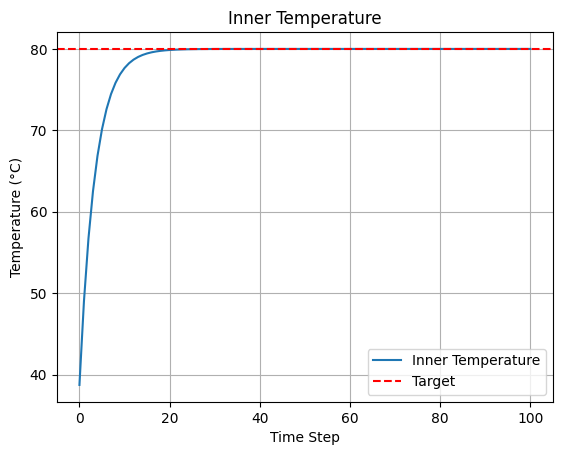

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
# from lib.callback.ppo_event_callback import PPOEventCallback
from stable_baselines3.common.vec_env import DummyVecEnv

inner_temp_history = []
action_history = []
reward_history = []
repeat_cnt = 100
learn_timesteps = -1
# trained_model_path_name ="./model/ppo_dryer_control_v1.1_20260329_231930.pth"  # 방금 저장한 모델 경로 사용

def test_model(model_path_name,
               repeat_cnt=100,
               reward_gen_fn_pathname=None,
               learn_timesteps=1,
               is_simulatation=True,
               simulation_cls_pathname=None,
               target_temp=80,
               verbose=0):
    """
    저장된 모델 로드 및 테스트
    """
    convergence_cnt = 0
    convergenced_cnt = 0
    convergenced_stats = False
    hit_point = 0
    
    # 1. 원본 환경 생성
    base_env = DryerEnv(reward_gen_fn_pathname=reward_gen_fn_pathname,
                        is_simulatation=is_simulatation,
                        simulation_cls_pathname=simulation_cls_pathname,
                        heater_input=const_heater_input)
    env = DummyVecEnv([lambda: Monitor(base_env)])
    model = RecurrentPPO.load(model_path_name, env)
    # 2. Monitor 래핑 (표준 규격 및 로그 기록)
    # model.env = env
    obs = model.env.reset()

    if isinstance(model.action_space, gym.spaces.Discrete):
        print("이 모델은 [이산(Discrete)] 환경용입니다. (Logits 사용 가능)")
    elif isinstance(model.action_space, gym.spaces.Box):
        print("이 모델은 [연속(Continuous)] 환경용입니다. (Logits 없음, MSE 사용 필요)")
    print(f'테스트를 시작합니다. [{datetime.now()}]')

    in_obs = obs
    print(f"in_obs = {in_obs}")

    inner_temp_history.append(in_obs[0][1])

    # LSTM 상태 초기화 (Recurrent 모델은 상태 관리가 필요함)
    lstm_states = None
    episode_starts = np.ones((1,), dtype=bool)
    for i in range(repeat_cnt):
        # 모델 예측 (deterministic=True: 가장 확률 높은 액션 선택)
        action, _ = model.predict(
            in_obs,
            state=lstm_states,
            episode_start=episode_starts,
            deterministic=True
        )
        step_results = model.env.step(action)
        predict_obs = step_results[0][0].tolist()
        diff = predict_obs[1] - in_obs[0][1]
        reward = step_results[1][0]
        if verbose > 0:
            if abs(diff) < 0.001:
                print(f"Step {i}: In ={in_obs}[{type(in_obs)}], Action={action}")            
                print(f"Step {i}: Out ={predict_obs}, Action={action}, Reward={reward:.2f}")
                print(f'not changed, diff = {diff}')
            else:
                print(f"Step {i}: In ={in_obs}[{type(in_obs)}], Action={action}")            
                print(f"Step {i}: Out ={predict_obs}, Action={action}, Reward={reward:.2f}")
        in_obs = [predict_obs]
        if i > 0 and learn_timesteps > 0 and i % learn_timesteps == 0:
            print(f"Step {i}: Learning from experience...")
            model.learn(total_timesteps=learn_timesteps, reset_num_timesteps=False, log_interval=None)
        inner_temp = predict_obs[1]
        inner_temp_history.append(inner_temp)
        action_history.append(int(action.item()))
        reward_history.append(reward)
        # if terminated or truncated:
        #     break

        #수렴 위치 측정
        if abs(inner_temp - target_temp) < 1.5:
            convergenced_stats = True
            convergence_cnt += 1
            if convergence_cnt > 3 and convergenced_stats == True and hit_point == 0:
                convergenced_cnt
                hit_point = i
        else:
            convergenced_stats = False
            convergence_cnt = 0
            hit_point = 0
        
    return hit_point


print(f"Testing model {trained_model_path_name} for {repeat_cnt} steps...")

hit_point = test_model(model_path_name=trained_model_path_name,
                       repeat_cnt=repeat_cnt,
                       reward_gen_fn_pathname=reward_gen_fn_pythonfile,
                       learn_timesteps=learn_timesteps,
                       is_simulatation=True,
                       simulation_cls_pathname=simulation_cls_pathname)

print(f'hit_point = {hit_point}')

plt.plot(inner_temp_history, label='Inner Temperature')
plt.axhline(80, color='r', linestyle='--', label='Target')
plt.title("Inner Temperature")
plt.xlabel('Time Step')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
## 아직 작업중인 코드입니다.

import numpy as np
from tqdm import tqdm


def evaluate_recurrent_ppo(model, env, n_eval_episodes=10, verbose=0):
    episode_rewards = []
    for i in tqdm(range(n_eval_episodes), desc="평가 진행 중"):
        obs = env.reset()
        done = False
        episode_reward = 0.0
        # LSTM 상태 초기화
        lstm_states = None
        # 에피소드 시작 시그널 (첫 스텝은 True)
        episode_starts = np.ones((env.num_envs,), dtype=bool)
        while not done:
            action, lstm_states = model.predict(
                obs, 
                state=lstm_states, 
                episode_start=episode_starts, 
                deterministic=True
            )
            obs, reward, done, info = env.step(action)
            episode_reward += reward
            episode_starts = done  # 다음 스텝의 리셋 여부 결정
            if verbose > 1:
                print(f'done={done}, obs={obs}')
        episode_rewards.append(episode_reward)
    return np.mean(episode_rewards), np.std(episode_rewards)

In [ ]:
## 아직 작업중인 코드입니다.

# 5. 성능 평가
is_simulatation = True
base_env = DryerEnv(reward_gen_fn_pathname=reward_gen_fn_pythonfile,
                    is_simulatation=is_simulatation,
                    simulation_cls_pathname=simulation_cls_pathname)
env = DummyVecEnv([lambda: base_env])
trained_model =  RecurrentPPO.load(trained_model_path_name, env)
n_eval_episodes = 5
print(f'성능 평가 시작')
mean_reward, std_reward = evaluate_recurrent_ppo(trained_model,
                                                 trained_model.get_env(),
                                                 n_eval_episodes=n_eval_episodes)
print(f"\n평균 보상: {mean_reward:.2f} +/- {std_reward:.2f}")
